### Datos faltantes: análisis inicial

Identificación de columnas con valores nulos y su posible relación con otras variables.

In [14]:
import pandas as pd 
import numpy as np
from IPython.display import display
import sys, os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu
import missingno as msno
%matplotlib inline
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
#from functions.transformers import *
from functions.eda_functions import test_mcar, list_missing_values

In [15]:
df_train_raw = pd.read_csv('../data/raw/train.csv').drop('Id', axis=1)
df_train = df_train_raw.copy()
print(f'start dimensions: {df_train.shape}')
df_train.head()

start dimensions: (1460, 80)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [16]:
list_missing_values(df_train)

,missing counts,percentage(%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


-- PoolQC ---
[nan 'Ex' 'Fa' 'Gd']


,count,percentage(%)
PoolQC,,
NaN,1453,99.52
Gd,3,0.21
Ex,2,0.14
Fa,2,0.14


,PoolArea,PoolQC
197,512,Ex
810,648,Fa
1170,576,Gd
1182,555,Ex
1298,480,Gd
1386,519,Fa
1423,738,Gd


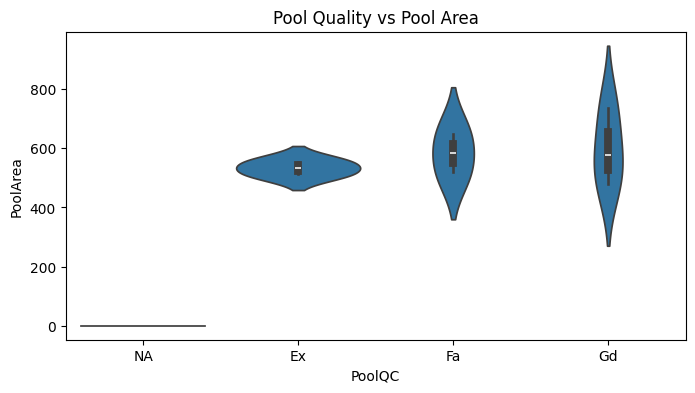

In [17]:
#PoolQC: Calidad de la piscina.
print(f"-- PoolQC ---")
#Visualización de los datos faltantes, cantidad y porcentaje
print(df_train['PoolQC'].unique())
missing_poolqc = pd.DataFrame(df_train['PoolQC'].value_counts(dropna=False))
missing_poolqc['percentage(%)'] = np.round(missing_poolqc['count'] / df_train.shape[0] * 100, 2)
display(missing_poolqc)
#Visualización de los datos faltantes, area de piscina frente a calidad de piscina
res = df_train[df_train['PoolArea'] > 0]
display(res[['PoolArea', 'PoolQC']])
#Imputación de los datos faltantes
df_train.loc[:, 'PoolQC'] = df_train['PoolQC'].fillna('NA')
#Visualización de la relación entre PoolQC y PoolArea graficamente
plt.figure(figsize=(8,4))
sns.violinplot(x='PoolQC', y='PoolArea', data=df_train)
plt.title('Pool Quality vs Pool Area')
plt.show()
#PoolQC: Calidad de la piscina. depende de PoolArea. Si PoolArea es 0, PoolQC es NA.
#MNAR Las features estan relacionadas. Se puede imputar. No son aleatorias.

-- MiscFeature ---


,count,percentage(%)
MiscFeature,,
NaN,1406,96.30
Shed,49,3.36
Gar2,2,0.14
Othr,2,0.14
TenC,1,0.07


,MiscFeature,MiscVal
5,Shed,700
7,Shed,350
16,Shed,700
17,Shed,500
51,Shed,400
84,Shed,700
95,Shed,480
98,Shed,400
99,Shed,400
106,Shed,450


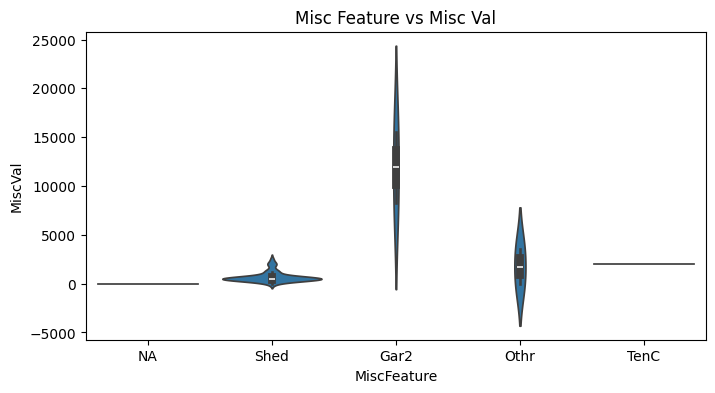

In [18]:
#MiscFeature: Característica miscelánea no cubierta en otras categorías.
print(f"-- MiscFeature ---")
#MiscVal: Valor monetario de la característica miscelánea.
#Visualización de los datos faltantes, cantidad y porcentaje
missing_miscFeature = pd.DataFrame(df_train['MiscFeature'].value_counts(dropna=False))
missing_miscFeature['percentage(%)'] = np.round(missing_miscFeature['count'] / df_train.shape[0] * 100, 2)
display(missing_miscFeature)
#visualizar las filas con datos faltantes en MiscFeature y su relación con MiscVal
match_miscval = df_train[df_train['MiscVal'] > 0]
display(match_miscval[['MiscFeature', 'MiscVal']])
#Imputación de los datos faltantes
df_train.loc[:, 'MiscFeature'] = df_train['MiscFeature'].fillna('NA')
#Visualizacion de la relación entre MiscFeature y MiscVal graficamente
plt.figure(figsize=(8,4))
sns.violinplot(x='MiscFeature', y='MiscVal', data=df_train)
plt.title('Misc Feature vs Misc Val')
plt.show()
#MiscFeature: Característica miscelánea no cubierta en otras categorías. Depende de MiscVal. Si MiscVal es 0, MiscFeature es NA.
#MNAR Las features estan relacionadas. Se puede imputar. No son aleatorias.

-- Alley ---


,count,percentage(%)
Alley,,
NaN,1369,93.77
Grvl,50,3.42
Pave,41,2.81


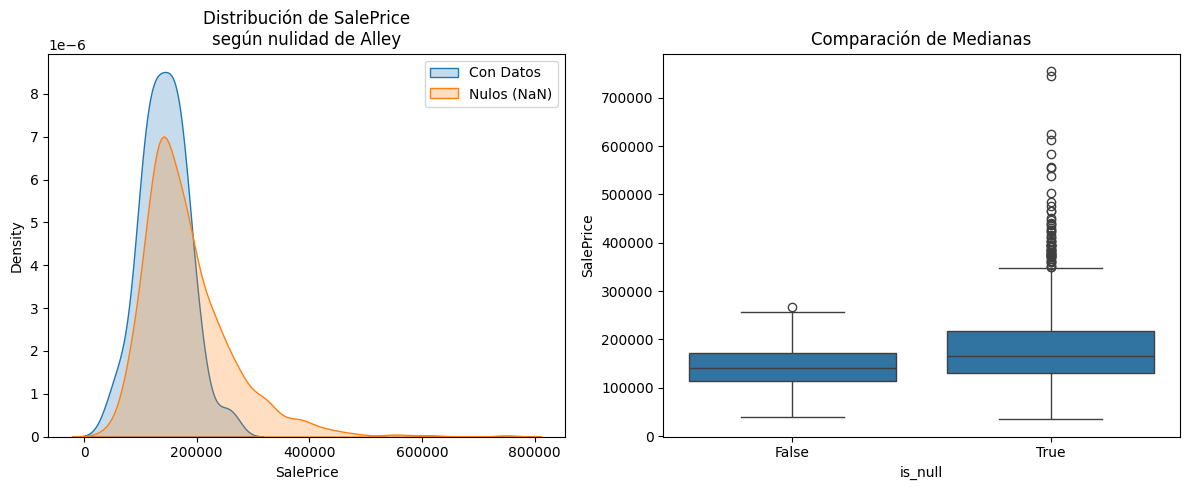

--- Diagnóstico para Alley ---
P-Valor de la prueba Mann-Whitney: 0.0000
Resultado: Diferencia significativa detectada. Es MAR o MNAR (No aleatorio).
group lotArea by Alley


,Alley,count,mean
0,Grvl,50,8932.500000
1,NA,1369,10711.370343
2,Pave,41,5953.121951


group SalePrice by Alley


,Alley,count,mean
0,Grvl,50,122219.080000
1,NA,1369,183452.131483
2,Pave,41,168000.585366


group LotFrontage by Alley


,Alley,count,mean
0,Grvl,47,61.744681
1,NA,1115,71.217937
2,Pave,39,46.666667


In [19]:
#Alley: Tipo de acceso por callejón a la propiedad.
print(f"-- Alley ---")
#Visualización de los datos faltantes, cantidad y porcentaje
missing_alley = pd.DataFrame(df_train['Alley'].value_counts(dropna=False))
missing_alley['percentage(%)'] = np.round(missing_alley['count'] / df_train.shape[0] * 100, 2)
display(missing_alley)
#visualizar las filas con datos faltantes en Alley y su relación con LotFrontage
test_mcar(df_train, 'Alley')
df_train.loc[:, 'Alley'] = df_train['Alley'].fillna('NA')
print('group lotArea by Alley')
display(df_train.groupby(['Alley'])['LotArea'].agg(['count', 'mean']).reset_index())
print('group SalePrice by Alley')
display(df_train.groupby(['Alley'])['SalePrice'].agg(['count', 'mean']).reset_index())
print('group LotFrontage by Alley')
display(df_train.groupby(['Alley'])['LotFrontage'].agg(['count', 'mean']).reset_index())
#Imputación de los datos faltantes con valor NA, que indica que no tiene callejon.
#Se analizo una posible MCAR, pero no se encontró evidencia suficiente.
#Se determino en la comparacion que tiene un manejo diferente los grupos donde Alley es NA y donde no lo es.
#Se define como MAR, ya que las casas sin callejon tienen a ser mas caras

#En las agrupaciones con LotArea, SalePrice y LotFrontage se observa que las propiedades sin Alley (NA) tienen promedios más altos en comparación con las que tienen Alley.
#Esto sugiere que la ausencia de Alley está asociada con propiedades más grandes y valiosas.
#MAR Las features estan relacionadas. Se puede imputar. No son aleatorias.

-- Fence ---


,count,percentage(%)
Fence,,
NaN,1179,80.75
MnPrv,157,10.75
GdPrv,59,4.04
GdWo,54,3.70
MnWw,11,0.75


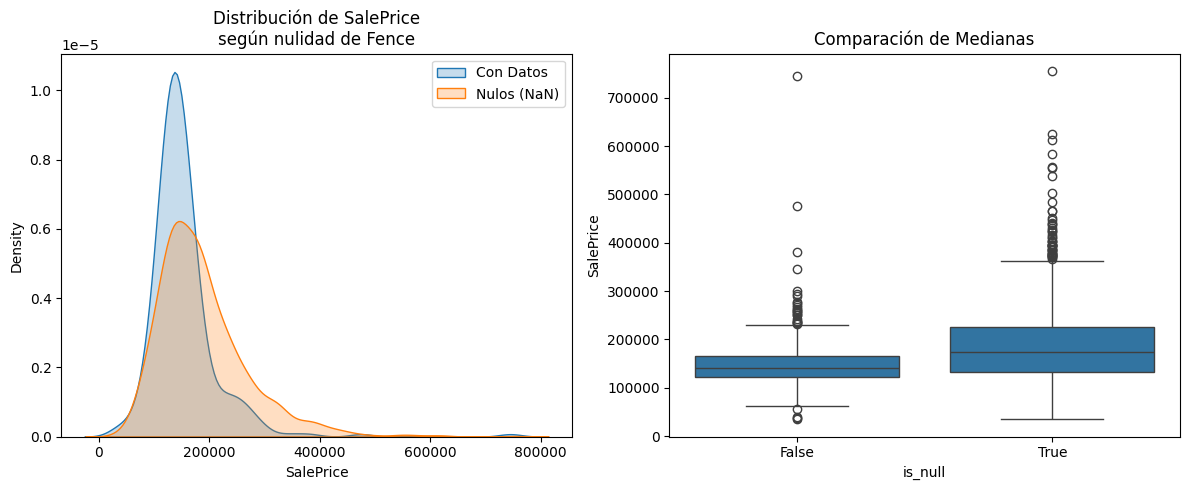

--- Diagnóstico para Fence ---
P-Valor de la prueba Mann-Whitney: 0.0000
Resultado: Diferencia significativa detectada. Es MAR o MNAR (No aleatorio).
group LotArea by Fence


,Fence,count,mean
4,NA,1179,10743.659881
0,GdPrv,59,10520.288136
1,GdWo,54,9634.018519
3,MnWw,11,9250.909091
2,MnPrv,157,9204.458599


group LotFrontage by Fence


,Fence,count,mean
0,GdPrv,48,73.687500
1,GdWo,42,73.666667
2,MnPrv,128,70.562500
4,NA,973,69.653649
3,MnWw,10,69.400000


group SalePrice by Fence


,Fence,count,mean
4,NA,1179,187596.837998
0,GdPrv,59,178927.457627
2,MnPrv,157,148751.089172
1,GdWo,54,140379.314815
3,MnWw,11,134286.363636


In [20]:
#Fence: Tipo de cerca alrededor de la propiedad.
print(f"-- Fence ---")
#Visualización de los datos faltantes, cantidad y porcentaje
missing_fence = pd.DataFrame(df_train['Fence'].value_counts(dropna=False))
missing_fence['percentage(%)'] = np.round(missing_fence['count'] / df_train.shape[0] * 100, 2)
display(missing_fence)
test_mcar(df_train, 'Fence')
df_train.loc[:, 'Fence'] = df_train['Fence'].fillna('NA')
print('group LotArea by Fence')
display(df_train.groupby(['Fence'])['LotArea'].agg(['count', 'mean']).reset_index().sort_values(by='mean', ascending=False))
print('group LotFrontage by Fence')
display(df_train.groupby(['Fence'])['LotFrontage'].agg(['count', 'mean']).reset_index().sort_values(by='mean', ascending=False))
print('group SalePrice by Fence')
display(df_train.groupby(['Fence'])['SalePrice'].agg(['count', 'mean']).reset_index().sort_values(by='mean', ascending=False))
#Imputación de los datos faltantes con valor NA, que indica que no tiene cerca.
#Se analizo una posible MCAR, pero no se encontró evidencia suficiente.
#Se determino en la comparacion que tiene un manejo diferente los grupos donde Fence es NA y donde no lo es.
#Se define como MAR, ya que las casas sin cerca tienen a ser mas caras

In [21]:
#MasVnrType: Tipo de revestimiento de mampostería.
print(f"-- MasVnrType ---")
#Visualización de los datos faltantes, cantidad y porcentaje
missing_masvnrtype = pd.DataFrame(df_train['MasVnrType'].value_counts(dropna=False))
missing_masvnrtype['percentage(%)'] = np.round(missing_masvnrtype['count'] / df_train.shape[0] * 100, 2)
display(missing_masvnrtype)
#Se da por hecho que si MasVnrArea es 0, entonces MasVnrType es NA
condition_impute = (df_train['MasVnrType'].isnull()) & (df_train['MasVnrArea'] == 0)
df_train.loc[condition_impute, 'MasVnrType'] = df_train['MasVnrType'].fillna('NA')
#Basado en Foundation: cimientos se imputa por el valor similar CBlock y Pconc
condition_impute2 = (df_train['MasVnrType'].isnull()) & ((df_train['Foundation'] == 'CBlock') | (df_train['Foundation'] == 'PConc'))
df_train.loc[condition_impute2, 'MasVnrType'] = df_train['MasVnrType'].fillna('CBlock')
df_train['MasVnrType'].unique()

-- MasVnrType ---


,count,percentage(%)
MasVnrType,,
NaN,872,59.73
BrkFace,445,30.48
Stone,128,8.77
BrkCmn,15,1.03


array(['BrkFace', 'NA', 'Stone', 'BrkCmn', 'CBlock'], dtype=object)

In [22]:
#FireplaceQu: Calidad de la chimenea.
print(f"-- FireplaceQu ---")
#Visualización de los datos faltantes, cantidad y porcentaje
missing_fireplacequ = pd.DataFrame(df_train['FireplaceQu'].value_counts(dropna=False))
missing_fireplacequ['percentage(%)'] = np.round(missing_fireplacequ['count'] / df_train.shape[0] * 100, 2)
display(missing_fireplacequ)
#Se da por hecho que si Fireplaces es 0, entonces FireplaceQu es NA
condition_fireplacequ = (df_train['FireplaceQu'].isnull()) & (df_train['Fireplaces'] == 0)
df_train.loc[condition_fireplacequ, 'FireplaceQu'] = df_train['FireplaceQu'].fillna('NA')

-- FireplaceQu ---


,count,percentage(%)
FireplaceQu,,
NaN,690,47.26
Gd,380,26.03
TA,313,21.44
Fa,33,2.26
Ex,24,1.64
Po,20,1.37


In [ ]:
#LotFrontage: Metros lineales de la calle conectada a la propiedad.
print(f"-- LotFrontage ---")

,missing counts,percentage(%)
LotFrontage,259,17.74
GarageYrBlt,81,5.55
GarageFinish,81,5.55
GarageQual,81,5.55
GarageType,81,5.55
GarageCond,81,5.55
BsmtFinType2,38,2.60
BsmtExposure,38,2.60
BsmtQual,37,2.53
BsmtFinType1,37,2.53
